In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры сигнала и дискретизации
fs = 2000              # частота дискретизации, Гц
T = 1.0                # длительность сигнала, с
N = int(fs * T)        # количество отсчётов
t = np.arange(N) / fs  # массив времени

# Частоты составляющих сигнала
f1, f2, f3 = 50, 150, 450

# Параметры фильтра Баттерворта
fc = 120               # частота среза, Гц (можно менять в диапазоне 70…120)

Пункт 1


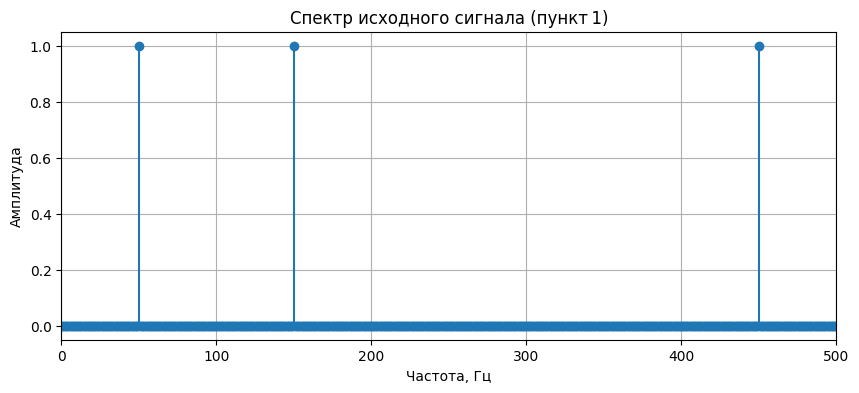

In [14]:
# Сумма трёх косинусоид с амплитудой 1
x = (np.cos(2 * np.pi * f1 * t) +
     np.cos(2 * np.pi * f2 * t) +
     np.cos(2 * np.pi * f3 * t))

# Вычисление спектра через БПФ
X = np.fft.fft(x)
freq = np.fft.fftfreq(N, 1/fs)      # все частоты (включая отрицательные)
w = 2 * np.pi * freq                # угловые частоты

# Визуализация спектра исходного сигнала (для контроля)
plt.figure(figsize=(10, 4))
pos_idx = freq >= 0
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр исходного сигнала (пункт 1)')
plt.xlim(0, 500)
plt.grid(True)
plt.show()

Пункт 2

In [15]:
# Угловая частота среза
wc = 2 * np.pi * fc

# Частотная характеристика фильтра по формуле (32)
# H(w) = wc^2 / (-w^2 + 1j*sqrt(2)*wc*w + wc^2)
H = wc**2 / (-w**2 + 1j * np.sqrt(2) * wc * w + wc**2)

# Применение фильтра к спектру сигнала (умножение в частотной области)
Y = X * H

# Обратное БПФ – получение отфильтрованного сигнала (берём действительную часть)
y = np.fft.ifft(Y).real

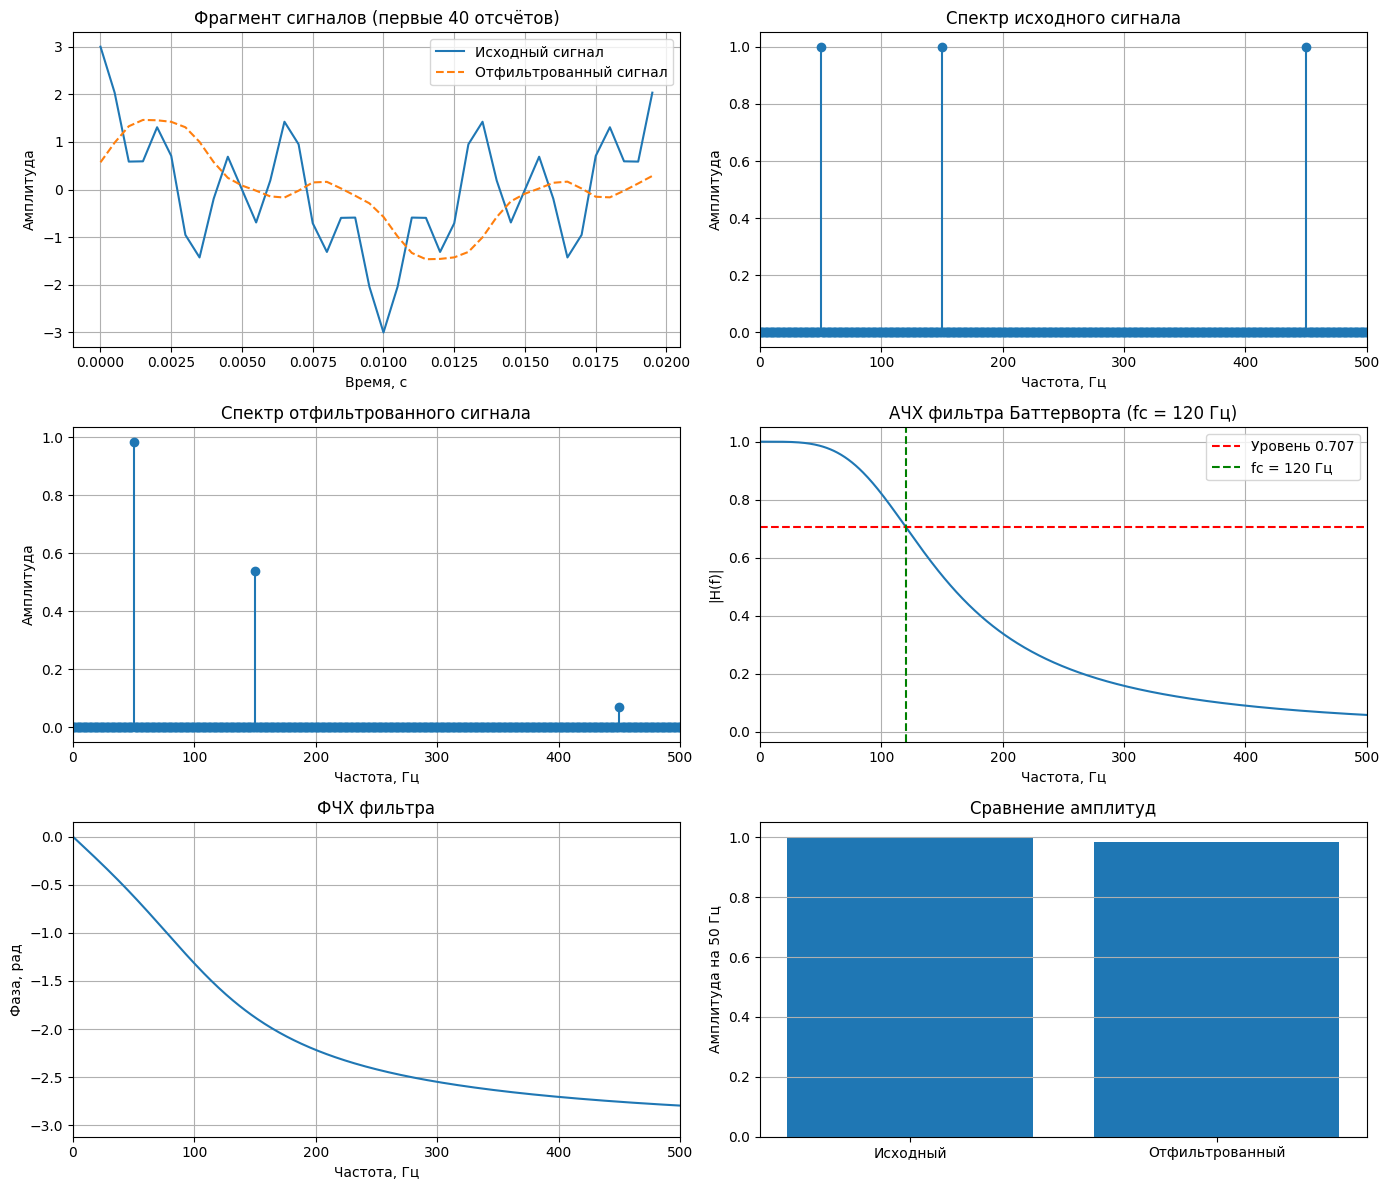

Амплитуда исходного сигнала на частоте 50 Гц: 1.0000
Амплитуда отфильтрованного сигнала на частоте 50 Гц: 0.9853
Отношение: 0.9853


In [16]:
# Создание фигуры с шестью подграфиками
plt.figure(figsize=(14, 12))

# 1. Исходный и отфильтрованный сигналы (первые 40 отсчётов)
plt.subplot(3, 2, 1)
plt.plot(t[:40], x[:40], label='Исходный сигнал')
plt.plot(t[:40], y[:40], '--', label='Отфильтрованный сигнал')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title('Фрагмент сигналов (первые 40 отсчётов)')
plt.legend()
plt.grid(True)

# 2. Амплитудный спектр исходного сигнала (положительные частоты)
plt.subplot(3, 2, 2)
pos_idx = freq >= 0
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр исходного сигнала')
plt.xlim(0, 500)
plt.grid(True)

# 3. Амплитудный спектр отфильтрованного сигнала
plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр отфильтрованного сигнала')
plt.xlim(0, 500)
plt.grid(True)

# 4. АЧХ фильтра (модуль H)
plt.subplot(3, 2, 4)
plt.plot(freq[pos_idx], np.abs(H[pos_idx]))
plt.xlabel('Частота, Гц')
plt.ylabel('|H(f)|')
plt.title(f'АЧХ фильтра Баттерворта (fc = {fc} Гц)')
plt.xlim(0, 500)
plt.axhline(1/np.sqrt(2), color='r', linestyle='--', label='Уровень 0.707')
plt.axvline(fc, color='g', linestyle='--', label=f'fc = {fc} Гц')
plt.legend()
plt.grid(True)

# 5. ФЧХ фильтра (аргумент H)
plt.subplot(3, 2, 5)
plt.plot(freq[pos_idx], np.angle(H[pos_idx]))
plt.xlabel('Частота, Гц')
plt.ylabel('Фаза, рад')
plt.title('ФЧХ фильтра')
plt.xlim(0, 500)
plt.grid(True)

# 6. Сравнение амплитуды на частоте 50 Гц
idx_50 = np.argmin(np.abs(freq - 50))
A_orig = np.abs(X[idx_50]) * 2 / N
A_filt = np.abs(Y[idx_50]) * 2 / N
plt.subplot(3, 2, 6)
plt.bar(['Исходный', 'Отфильтрованный'], [A_orig, A_filt])
plt.ylabel('Амплитуда на 50 Гц')
plt.title('Сравнение амплитуд')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# Вывод численных значений
print(f'Амплитуда исходного сигнала на частоте 50 Гц: {A_orig:.4f}')
print(f'Амплитуда отфильтрованного сигнала на частоте 50 Гц: {A_filt:.4f}')
print(f'Отношение: {A_filt/A_orig:.4f}')

### Пункт 3: Фильтр высоких частот (ФВЧ) 2-го порядка по формуле (35)


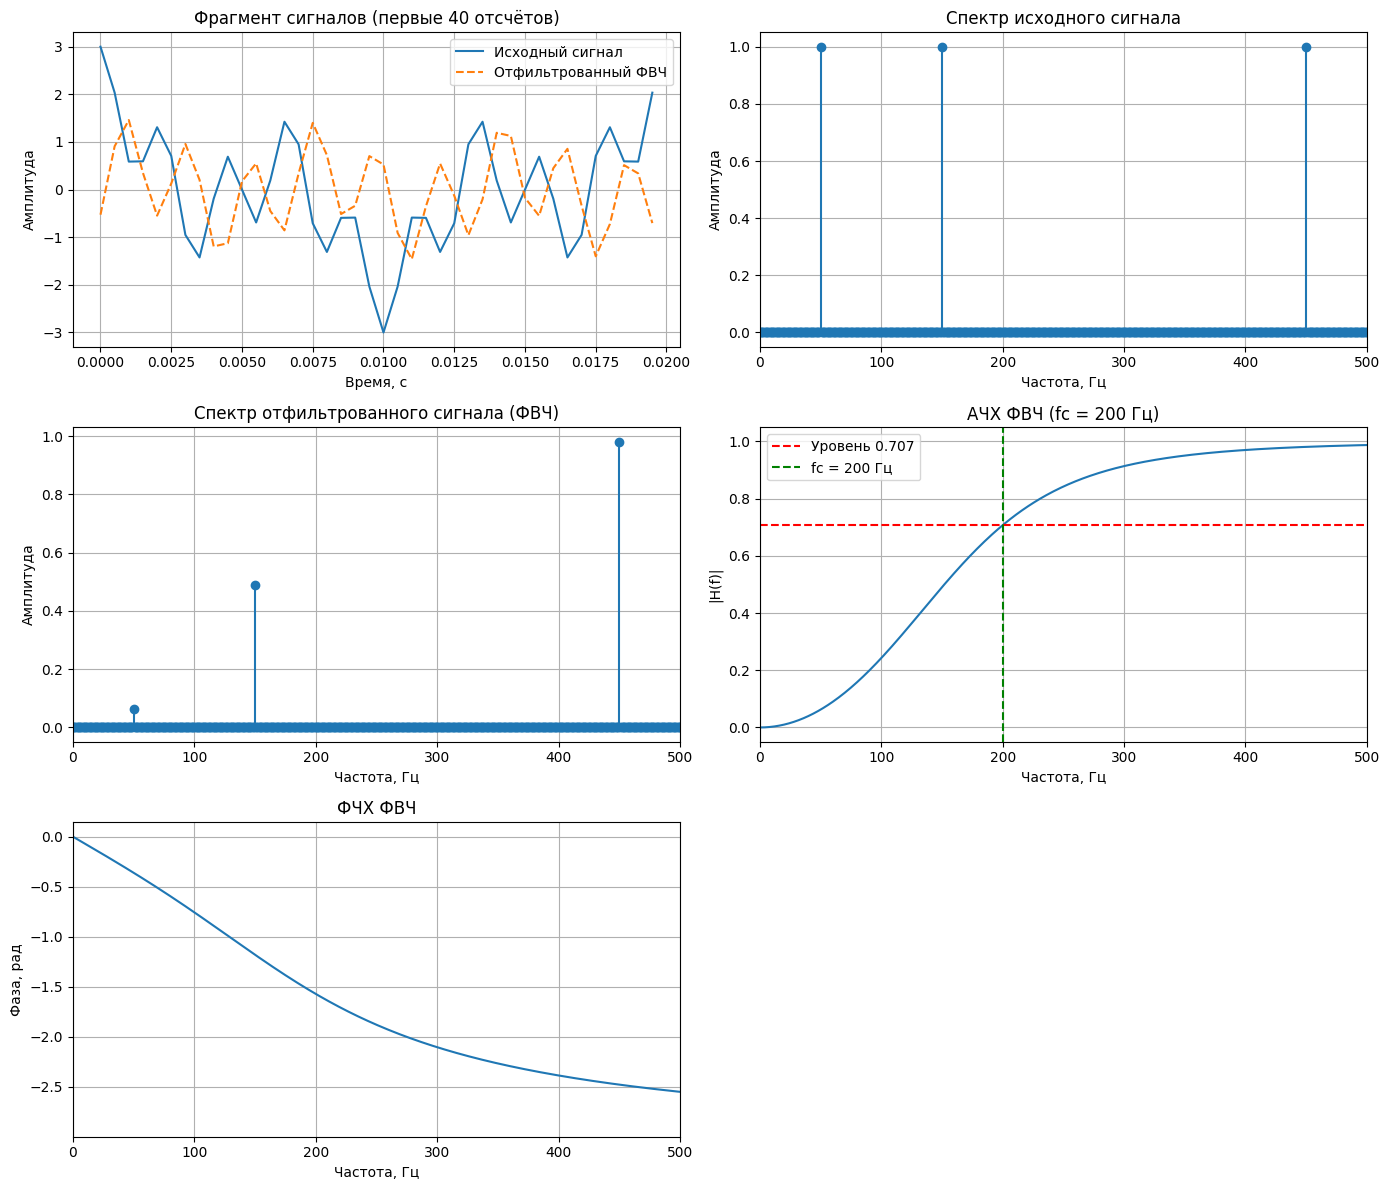

Амплитуда на 50 Гц после ФВЧ: 0.0624
Амплитуда на 150 Гц после ФВЧ: 0.4903


In [18]:


fc_high = 200  # Частота среза для ФВЧ, Гц
wc_high = 2 * np.pi * fc_high

H_high = w**2 / (-w**2 + 1j * np.sqrt(2) * wc_high * w + wc_high**2)

Y_high = X * H_high
y_high = np.fft.ifft(Y_high).real

# Графики аналогично пункту 2
plt.figure(figsize=(14, 12))

plt.subplot(3, 2, 1)
plt.plot(t[:40], x[:40], label='Исходный сигнал')
plt.plot(t[:40], y_high[:40], '--', label='Отфильтрованный ФВЧ')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title('Фрагмент сигналов (первые 40 отсчётов)')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр исходного сигнала')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y_high[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр отфильтрованного сигнала (ФВЧ)')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(freq[pos_idx], np.abs(H_high[pos_idx]))
plt.xlabel('Частота, Гц')
plt.ylabel('|H(f)|')
plt.title(f'АЧХ ФВЧ (fc = {fc_high} Гц)')
plt.xlim(0, 500)
plt.axhline(1/np.sqrt(2), color='r', linestyle='--', label='Уровень 0.707')
plt.axvline(fc_high, color='g', linestyle='--', label=f'fc = {fc_high} Гц')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 5)
plt.plot(freq[pos_idx], np.angle(H_high[pos_idx]))
plt.xlabel('Частота, Гц')
plt.ylabel('Фаза, рад')
plt.title('ФЧХ ФВЧ')
plt.xlim(0, 500)
plt.grid(True)

# Проверка на 50 и 150 Гц (должны быть подавлены)
idx_50 = np.argmin(np.abs(freq - 50))
idx_150 = np.argmin(np.abs(freq - 150))
A_filt_50 = np.abs(Y_high[idx_50]) * 2 / N
A_filt_150 = np.abs(Y_high[idx_150]) * 2 / N
# plt.subplot(3, 2, 6)
# plt.bar(['50 Гц', '150 Гц'], [A_filt_50, A_filt_150])
# plt.ylabel('Амплитуда после ФВЧ')
# plt.title('Подавление низких частот')
# plt.grid(axis='y')

plt.tight_layout()
plt.show()

print(f'Амплитуда на 50 Гц после ФВЧ: {A_filt_50:.4f}')
print(f'Амплитуда на 150 Гц после ФВЧ: {A_filt_150:.4f}')

### Пункт 4: Полосовой фильтр (ПФ) и заграждающий фильтр (ЗФ)

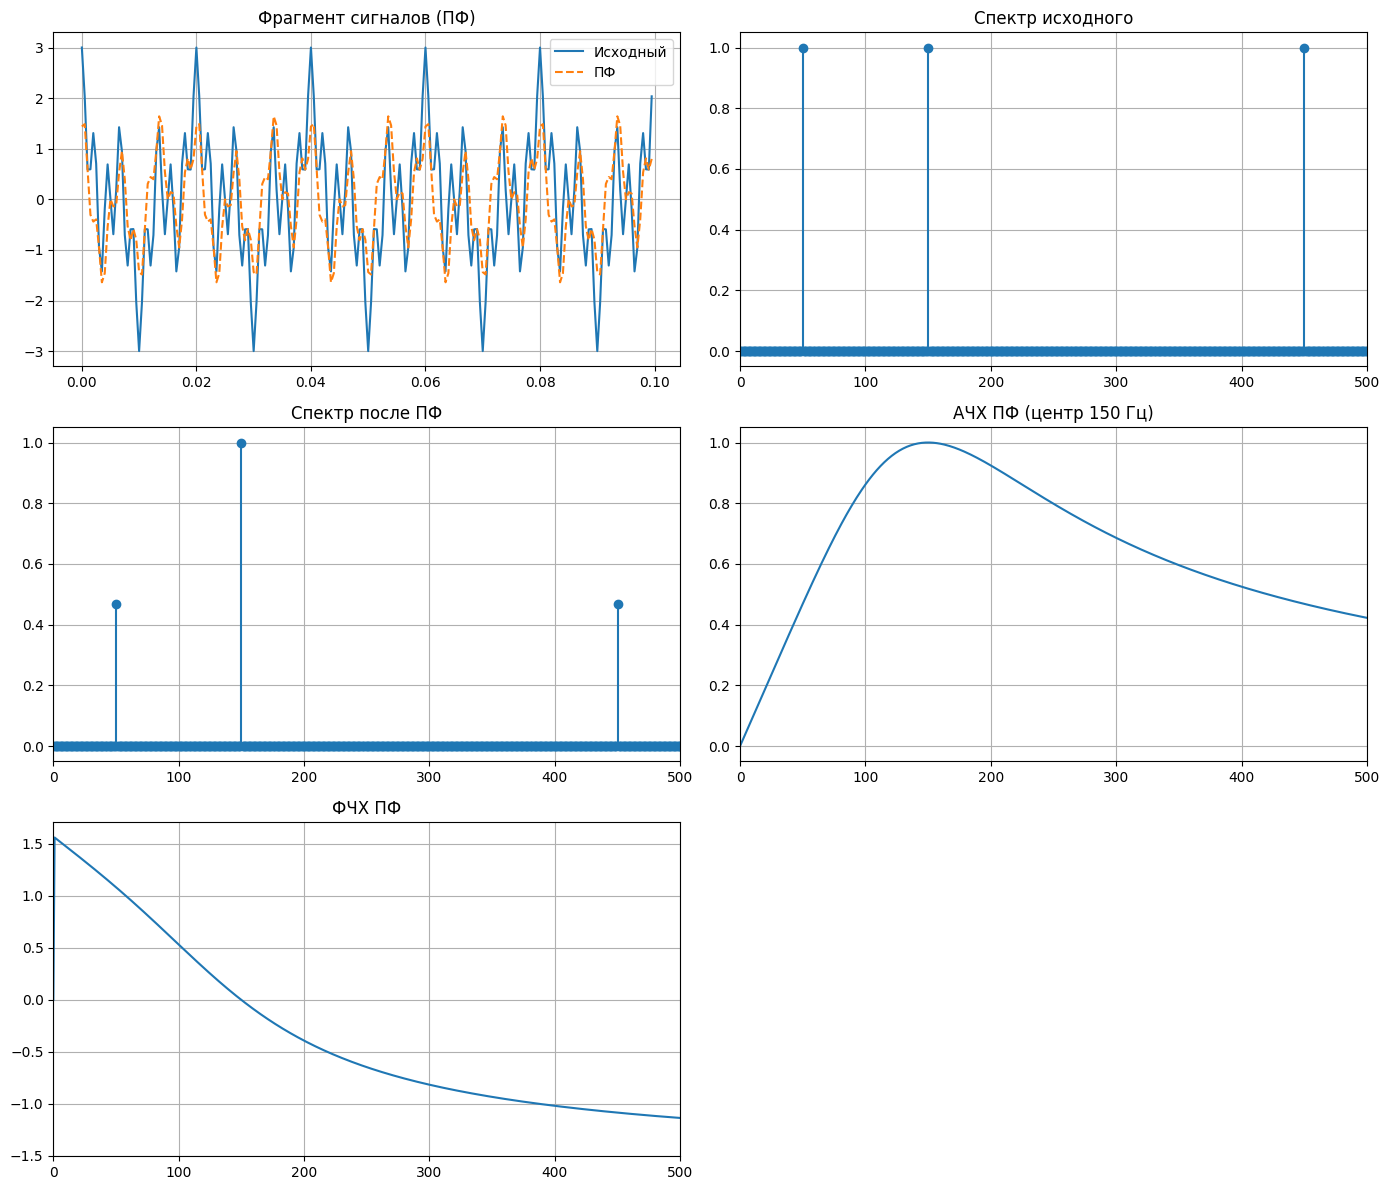

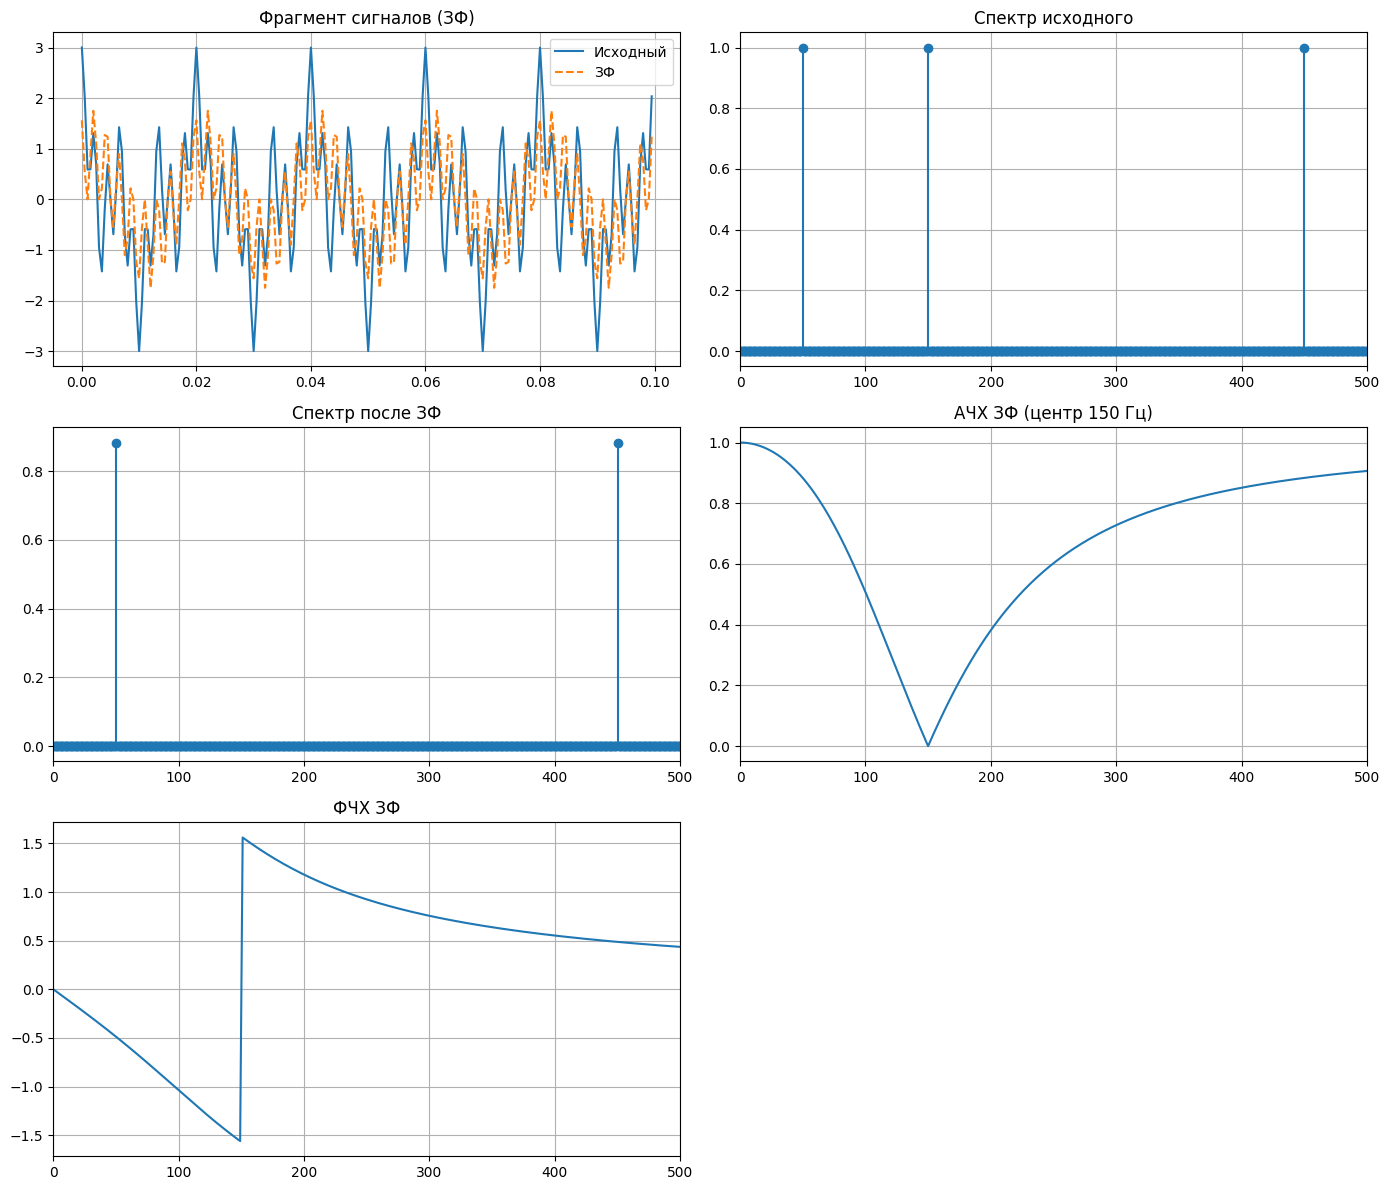

In [21]:


fc_band = 150
wc_band = 2 * np.pi * fc_band

# ПФ
H_band = 1j * np.sqrt(2) * wc_band * w / (-w**2 + 1j * np.sqrt(2) * wc_band * w + wc_band**2)
Y_band = X * H_band
y_band = np.fft.ifft(Y_band).real

# ЗФ
H_notch = (-w**2 + wc_band**2) / (-w**2 + 1j * np.sqrt(2) * wc_band * w + wc_band**2)
Y_notch = X * H_notch
y_notch = np.fft.ifft(Y_notch).real

# Графики для ПФ
plt.figure(figsize=(14, 12))
plt.subplot(3, 2, 1)
plt.plot(t[:200], x[:200], label='Исходный')
plt.plot(t[:200], y_band[:200], '--', label='ПФ')
plt.title('Фрагмент сигналов (ПФ)')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр исходного')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y_band[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр после ПФ')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(freq[pos_idx], np.abs(H_band[pos_idx]))
plt.title(f'АЧХ ПФ (центр {fc_band} Гц)')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 5)
plt.plot(freq[pos_idx], np.angle(H_band[pos_idx]))
plt.title('ФЧХ ПФ')
plt.xlim(0, 500)
plt.grid(True)

idx_150 = np.argmin(np.abs(freq - 150))
A_orig_150 = np.abs(X[idx_150]) * 2 / N
A_band_150 = np.abs(Y_band[idx_150]) * 2 / N
# plt.subplot(3, 2, 6)
# plt.bar(['Исходный', 'ПФ'], [A_orig_150, A_band_150])
# plt.title('Амплитуда на 150 Гц (ПФ)')
# plt.grid(axis='y')

plt.tight_layout()
plt.show()

# Графики для ЗФ
plt.figure(figsize=(14, 12))
plt.subplot(3, 2, 1)
plt.plot(t[:200], x[:200], label='Исходный')
plt.plot(t[:200], y_notch[:200], '--', label='ЗФ')
plt.title('Фрагмент сигналов (ЗФ)')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр исходного')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y_notch[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр после ЗФ')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(freq[pos_idx], np.abs(H_notch[pos_idx]))
plt.title(f'АЧХ ЗФ (центр {fc_band} Гц)')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 5)
plt.plot(freq[pos_idx], np.angle(H_notch[pos_idx]))
plt.title('ФЧХ ЗФ')
plt.xlim(0, 500)
plt.grid(True)

A_notch_150 = np.abs(Y_notch[idx_150]) * 2 / N
# plt.subplot(3, 2, 6)
# plt.bar(['Исходный', 'ЗФ'], [A_orig_150, A_notch_150])
# plt.title('Амплитуда на 150 Гц (ЗФ)')
# plt.grid(axis='y')

plt.tight_layout()
plt.show()

### Пункт 5: ФНЧ Баттерворта 4-го и 5-го порядка

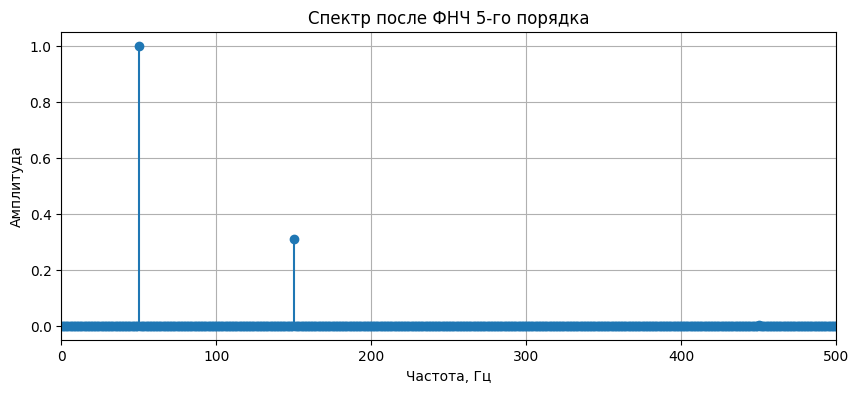

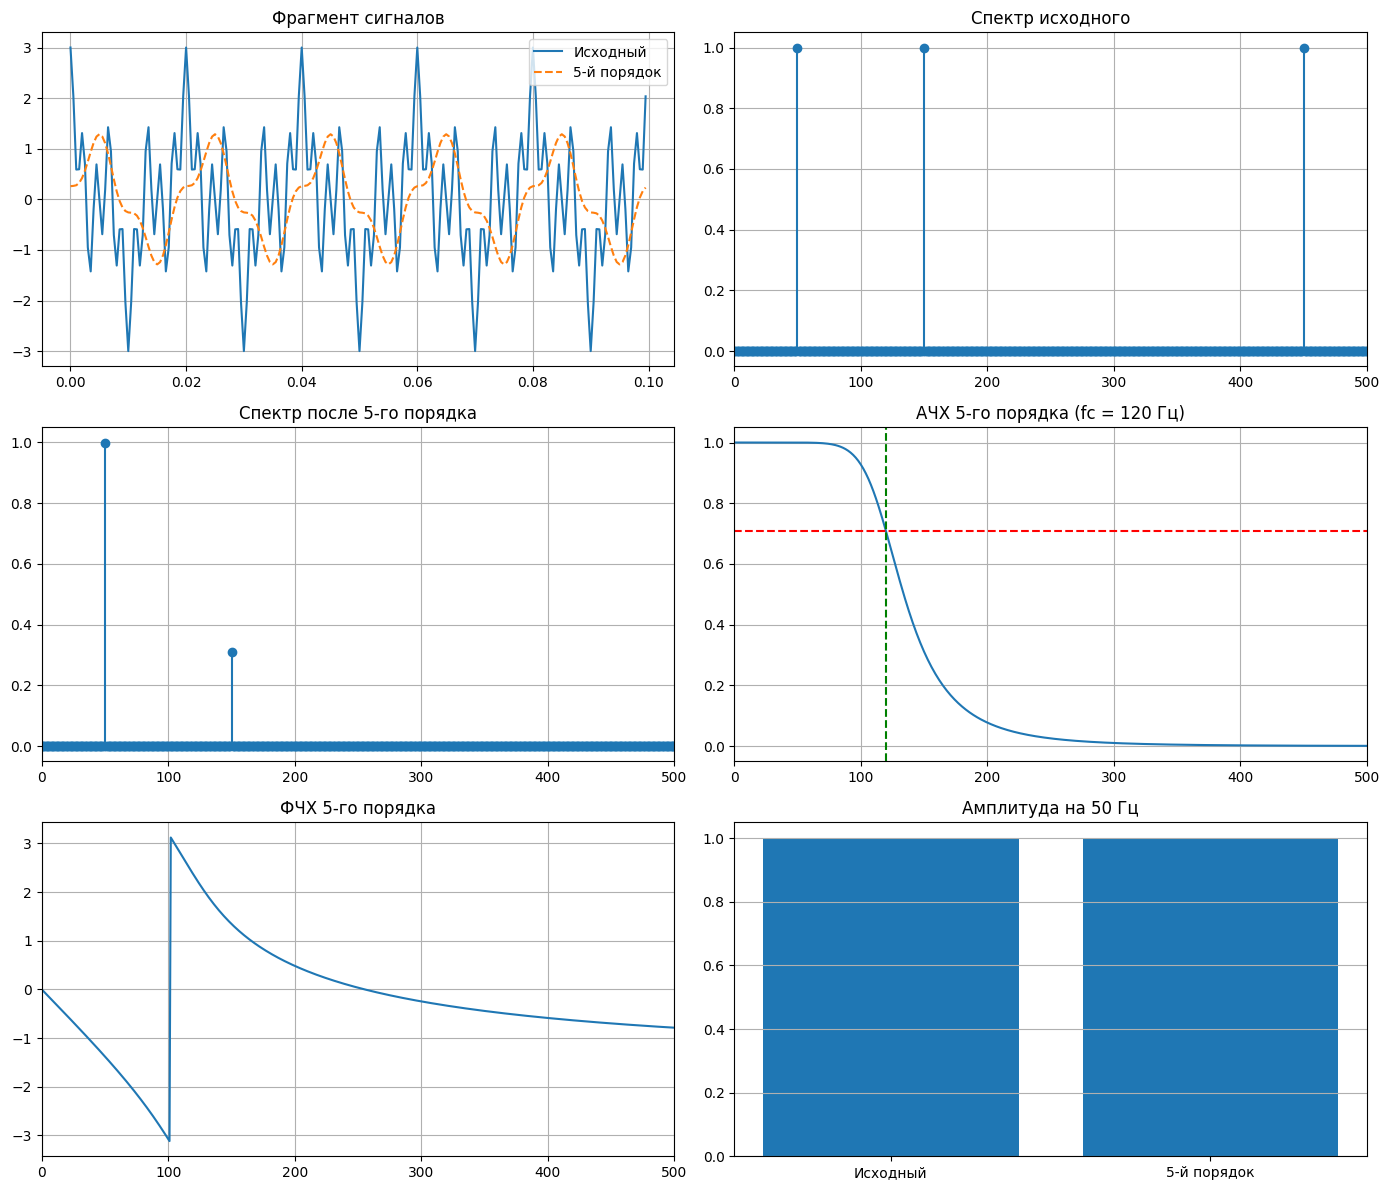

In [53]:
def butterworth_H(w, wc, n):
    poles = []
    for k in range(1, n + 1):
        theta = np.pi / 2 + (2 * k - 1) * np.pi / (2 * n)
        poles.append(wc * (np.cos(theta) + 1j * np.sin(theta)))
    
    H = wc**n * np.ones_like(w, dtype=complex)
    for p in poles:
        H /= (1j * w - p)
    
    H /= H[0]
    return H

# 4-й порядок
n4 = 4
H4 = butterworth_H(w, wc, n4)  # wc из пункта 2
Y4 = X * H4
y4 = np.fft.ifft(Y4).real

# 5-й порядок
n5 = 5
H5 = butterworth_H(w, wc, n5)
Y5 = X * H5
y5 = np.fft.ifft(Y5).real

# Спектр для 5-го (повтор пункта 1)
plt.figure(figsize=(10, 4))
plt.stem(freq[pos_idx], np.abs(Y5[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр после ФНЧ 5-го порядка')
plt.xlim(0, 500)
plt.grid(True)
plt.show()

# Графики для 5-го (аналогично пункту 2)
plt.figure(figsize=(14, 12))
plt.subplot(3, 2, 1)
plt.plot(t[:200], x[:200], label='Исходный')
plt.plot(t[:200], y5[:200], '--', label='5-й порядок')
plt.title('Фрагмент сигналов')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр исходного')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y5[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр после 5-го порядка')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(freq[pos_idx], np.abs(H5[pos_idx]))
plt.title(f'АЧХ 5-го порядка (fc = {fc} Гц)')
plt.xlim(0, 500)
plt.axhline(1/np.sqrt(2), color='r', ls='--')
plt.axvline(fc, color='g', ls='--')
plt.grid(True)

plt.subplot(3, 2, 5)
plt.plot(freq[pos_idx], np.angle(H5[pos_idx]))
plt.title('ФЧХ 5-го порядка')
plt.xlim(0, 500)
plt.grid(True)

A_filt5 = np.abs(Y5[idx_50]) * 2 / N
plt.subplot(3, 2, 6)
plt.bar(['Исходный', '5-й порядок'], [A_orig, A_filt5])
plt.title('Амплитуда на 50 Гц')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

### Пункт 6: Сравнение 2-го и 5-го порядка

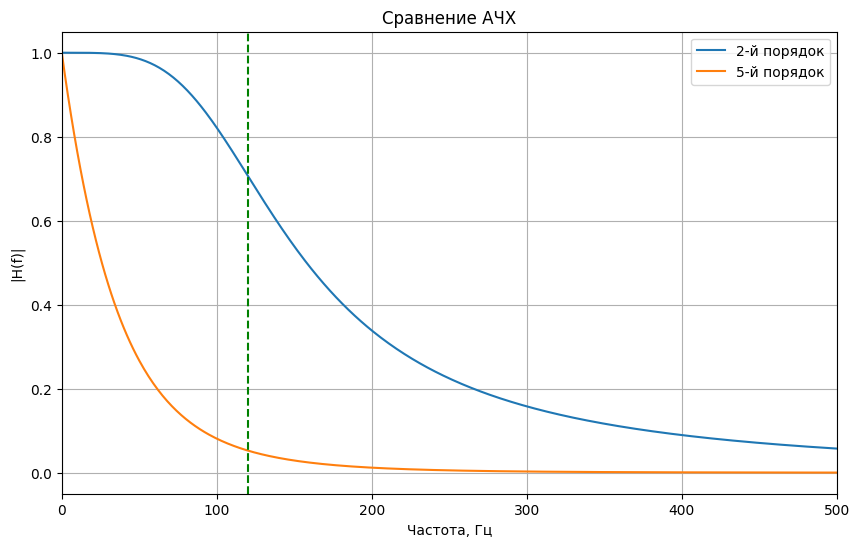

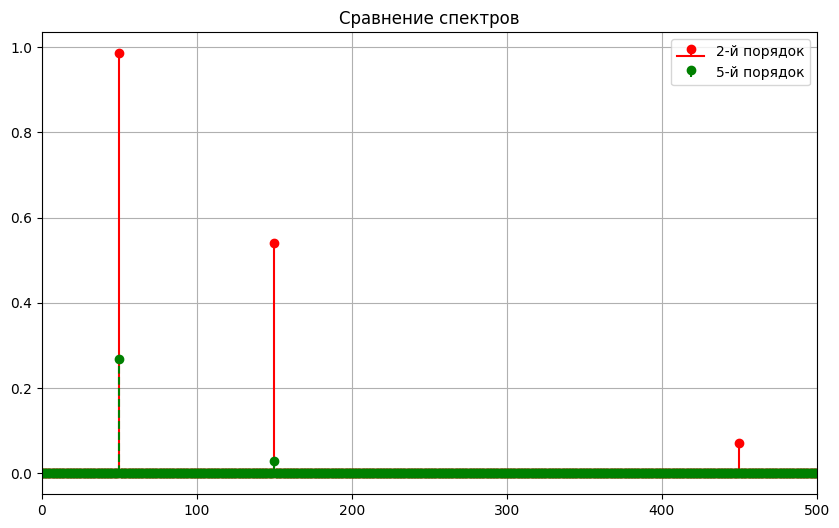

In [37]:

plt.figure(figsize=(10, 6))
plt.plot(freq[pos_idx], np.abs(H[pos_idx]), label='2-й порядок')
plt.plot(freq[pos_idx], np.abs(H5[pos_idx]), label='5-й порядок')
plt.xlabel('Частота, Гц')
plt.ylabel('|H(f)|')
plt.title('Сравнение АЧХ')
plt.xlim(0, 500)
plt.axvline(fc, color='g', ls='--')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.stem(freq[pos_idx], np.abs(Y[pos_idx]) * 2 / N, label='2-й порядок', basefmt='r', linefmt = 'r')
plt.stem(freq[pos_idx], np.abs(Y5[pos_idx]) * 2 / N, label='5-й порядок', basefmt=' ', linefmt = 'g--')
plt.title('Сравнение спектров')
plt.xlim(0, 500)
plt.legend()
plt.grid(True)
plt.show()

### Пункт 7: Сравнение с scipy для 5-го порядка

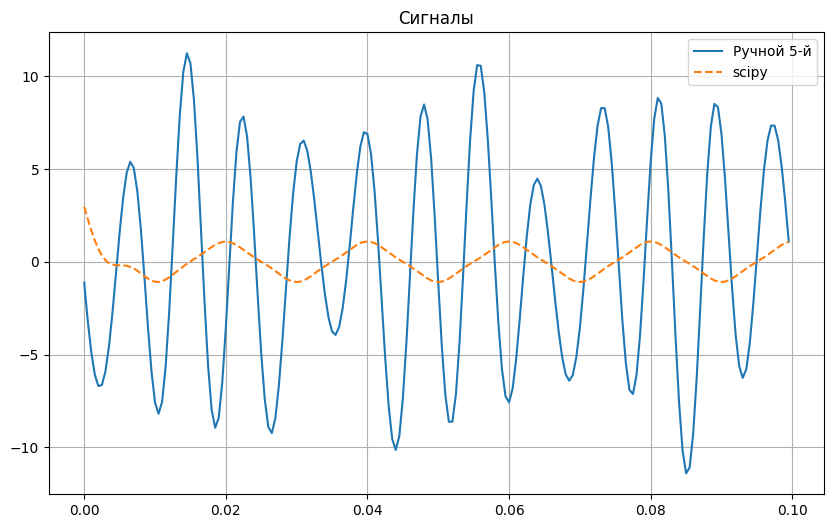

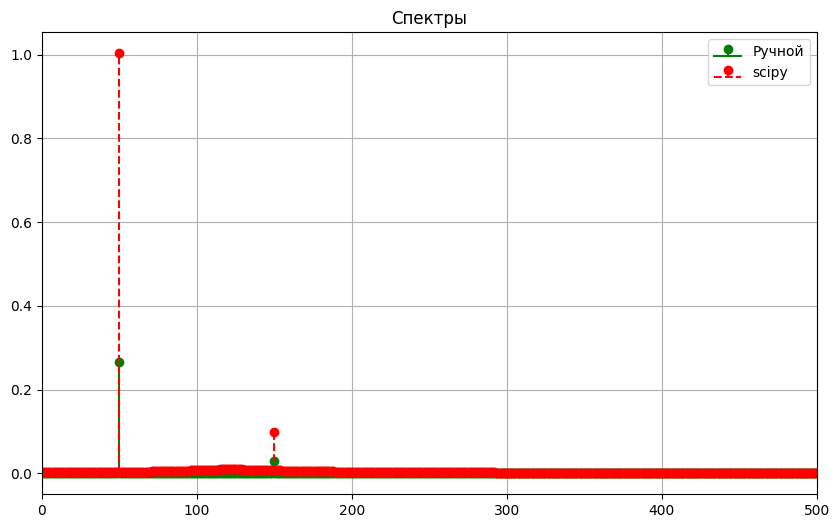

In [35]:

from scipy import signal

wn = fc / (fs / 2)
b_scipy, a_scipy = signal.butter(5, wn, 'low')
y_scipy = signal.filtfilt(b_scipy, a_scipy, x)  # filtfilt для нулевой фазы

Y_scipy = np.fft.fft(y_scipy)

plt.figure(figsize=(10, 6))
plt.plot(t[:200], y5[:200], label='Ручной 5-й')
plt.plot(t[:200], y_scipy[:200], '--', label='scipy')
plt.title('Сигналы')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.stem(freq[pos_idx], np.abs(Y5[pos_idx]) * 2 / N, 
         linefmt='g-', markerfmt='go', label='Ручной', basefmt='g-')

plt.stem(freq[pos_idx], np.abs(Y_scipy[pos_idx]) * 2 / N, 
         linefmt='r--', markerfmt='ro', label='scipy', basefmt='r--')
plt.title('Спектры')
plt.xlim(0, 500)
plt.legend()
plt.grid(True)
plt.show()

### Пункт 8: Шум + фильтрация

[ 2.57099935  2.47303345  0.80026721  0.54741887 -0.051298    1.05017358
 -1.4698582  -0.52301346 -0.21807628  1.50112404  0.20901849 -0.59284994
 -0.38423149  1.72372283  1.54149443  0.02762393 -1.28290046 -0.90636546
 -0.34051445 -1.72168228 -3.26971579 -2.39100034 -0.0471146  -0.24086675
 -2.19437091  0.23103016  0.80136549  0.82187301 -0.2353621  -0.92516503
 -0.40264754  0.72162903 -0.189946   -1.17626904 -0.51603909  0.3835772
  1.37869262  0.36546457  0.05856788  2.69308584  3.39653135  2.43409316
  0.2883697   0.72291525  2.30683322  1.22355849 -0.11875391 -1.12905386
 -0.35955589  1.33654089  0.11561184 -1.06324631 -0.09485845  0.80839694
  1.44988889 -0.56497709 -1.78170977 -1.09011083  0.19014392 -1.79550685
 -3.1252319  -3.28378029 -0.79177701  0.8021516  -1.08186812 -0.94147141
  1.2399654   0.92809509 -0.66815957 -0.78422365  0.80723877  0.29365023
  0.58505041 -1.53183068 -0.50696473  1.03525012  0.57658544  0.1512325
  1.23660159  1.87602895  2.71769979  2.08387413  0.6

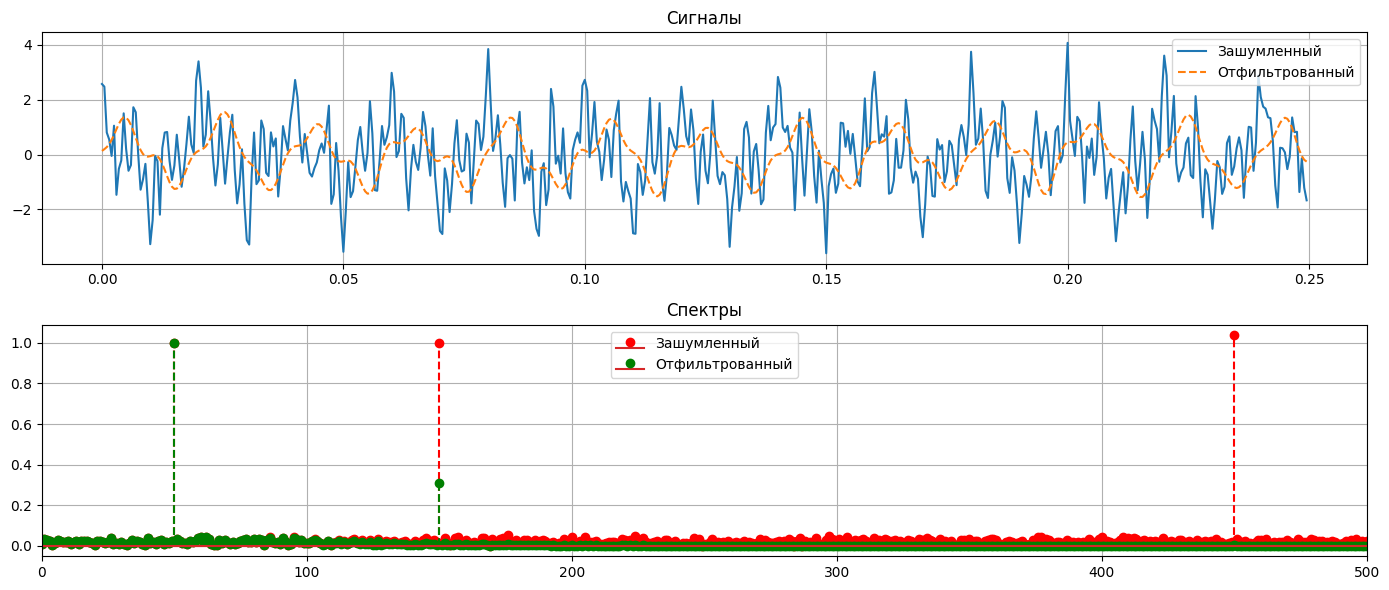

In [54]:

noise = np.random.normal(0, 0.5, N)
x_noisy = x + noise
X_noisy = np.fft.fft(x_noisy)

Y_noisy = X_noisy * H5
y_noisy_filt = np.fft.ifft(Y_noisy).real

print(x_noisy[:100])

plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(t[:500], x_noisy[:500], label='Зашумленный')
plt.plot(t[:500], y_noisy_filt[:500], '--', label='Отфильтрованный')
plt.title('Сигналы')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(freq[pos_idx], np.abs(X_noisy[pos_idx]) * 2 / N, label='Зашумленный', linefmt='r--')
plt.stem(freq[pos_idx], np.abs(Y_noisy[pos_idx]) * 2 / N, label='Отфильтрованный', linefmt='g--')
plt.title('Спектры')
plt.xlim(0, 500)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Пункт 9*: ФНЧ Чебышева 1-го рода N=5

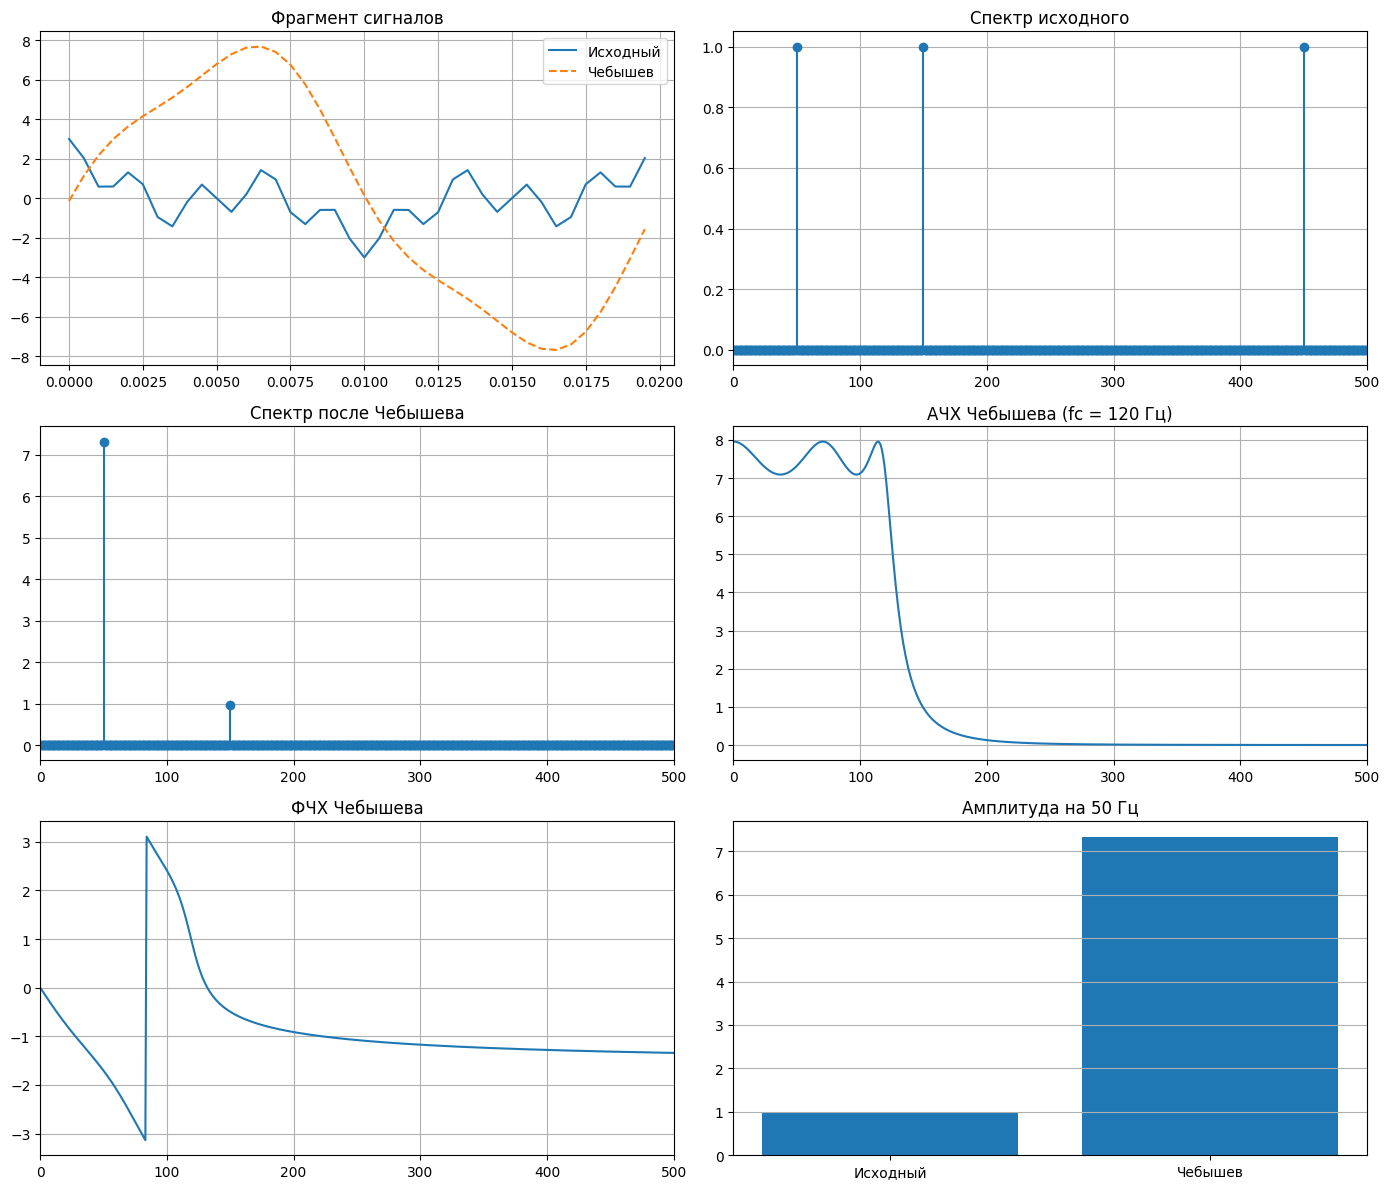

In [55]:

def chebyshev1_H(w, wc, n, ripple_db=1):
    epsilon = np.sqrt(10**(ripple_db / 10) - 1)
    mu = (1 / n) * np.arcsinh(1 / epsilon)
    
    poles = []
    for k in range(1, n + 1):
        phi = (2 * k - 1) * np.pi / (2 * n)
        sigma = -np.sinh(mu) * np.sin(phi)
        omega = np.cosh(mu) * np.cos(phi)
        poles.append(wc * (sigma + 1j * omega))
    
    H = wc**n * np.ones_like(w, dtype=complex)
    for p in poles:
        H /= (1j * w - p)
    
    # Нормализация DC gain ≈1
    if n % 2 == 0:
        H /= np.sqrt(1 + epsilon**2)
    else:
        H /= (1 + epsilon**2)**(1/(2*n))
    
    return H

H_cheb = chebyshev1_H(w, wc, 5, ripple_db=1)
Y_cheb = X * H_cheb
y_cheb = np.fft.ifft(Y_cheb).real

# Графики
plt.figure(figsize=(14, 12))
plt.subplot(3, 2, 1)
plt.plot(t[:40], x[:40], label='Исходный')
plt.plot(t[:40], y_cheb[:40], '--', label='Чебышев')
plt.title('Фрагмент сигналов')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр исходного')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y_cheb[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр после Чебышева')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(freq[pos_idx], np.abs(H_cheb[pos_idx]))
plt.title(f'АЧХ Чебышева (fc = {fc} Гц)')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 5)
plt.plot(freq[pos_idx], np.angle(H_cheb[pos_idx]))
plt.title('ФЧХ Чебышева')
plt.xlim(0, 500)
plt.grid(True)

A_cheb = np.abs(Y_cheb[idx_50]) * 2 / N
plt.subplot(3, 2, 6)
plt.bar(['Исходный', 'Чебышев'], [A_orig, A_cheb])
plt.title('Амплитуда на 50 Гц')
plt.grid(axis='y')

plt.tight_layout()
plt.show()